<a href="https://colab.research.google.com/github/tripathiosho/ImportantNotebooks/blob/main/Intro_to_Neural_Networks_Lecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Neural Networks

---

## Agenda

- **Pulse check on everything we know so far.** Take one dataset that our existing toolkit cannot handle cleanly, and diagnose precisely how each algorithm fails: logistic regression, KNN, decision trees, SVM.
- **Where the real gap is.** Separate the two jobs an algorithm does - inventing features and drawing a boundary - and identify which of the two we have been doing by hand all along.
- **Neural networks in everyday products.** Ranking and ads, data compression, image editing and enhancement, text prediction - what is common to all four.
- **Inspiration from the biological neuron.** Dendrites, signal strength, threshold and firing, and the exact machine-learning term each of these maps onto.
- **The mathematics of an artificial neuron.** The weighted sum, the bias, the geometry of what `w` and `b` do to a plane, and the activation function.
- **Why a neuron without an activation function is pointless.** A three-line proof that a stack of linear layers collapses into a single linear layer.
- **Logistic regression as a neural network.** Recognising a model we already built as one neuron, plus the forward-propagation vocabulary and matrix shapes.
- **Other single-neuron models.** Linear SVM and the perceptron - same skeleton, different activation.
- **From one neuron to a network.** How several neurons compose a curved boundary, and how to count the parameters of a layer.
- **A brief history of artificial neural networks.** 1957 to 2012, and the two bottlenecks that kept the field frozen in between.
- **Neural networks versus classical ML as data grows.** Why data volume decides which family wins.
- **AI Infusion.** Auditing AI-generated explanations, a reusable study-partner prompt, and the arithmetic that connects one neuron to a modern large model.

---

## The case we will carry through the session

**Hexa Cell** runs a lithium-ion cell plant. About forty thousand finished cells come off the line every day.

At the end of the line there is a small desk. Every cell is briefly put on a test rig that records exactly two cheap measurements, and then it gets sorted into one of three bins:

| Grade | Meaning | What happens to the cell |
|---|---|---|
| A | Healthy | Ships to the customer |
| B | Borderline | Goes back for rework |
| C | Faulty | Scrapped |

For eleven years that call has been made by one supervisor at that desk. She looks at the two numbers, and she says A, B or C. Her hit rate is famously good.

She retires in four months.

So the plant has handed us a file of past readings with her decisions attached, and one instruction: **build something that makes this call.**

### The two measurements

The rig reports two numbers, both already centred and scaled so that a perfectly nominal cell sits at zero:

- **`x1`** - internal resistance deviation. How far this cell's internal resistance sits from the nominal value for its batch. Negative means lower than nominal, positive means higher.
- **`x2`** - temperature-rise deviation. How far the cell's temperature rise during the test discharge sits from nominal. Again, negative is below nominal, positive is above.

And the label:

- **`y`** - the supervisor's grade, encoded as `0` for A, `1` for B, `2` for C.

### Reading the data

We will generate the file here so that the notebook runs anywhere without a download. Treat the output as the plant's historical log.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline


def load_hexa_cell_log(n_per_grade=400, seed=42):
    """
    Returns the plant's historical end-of-line log.

    x1 : internal resistance deviation from nominal
    x2 : temperature-rise deviation from nominal
    y  : supervisor's grade  (0 = A ship, 1 = B rework, 2 = C scrap)
    """
    rng = np.random.default_rng(seed)

    # A healthy cell sits near nominal on BOTH readings.
    # A borderline cell drifts moderately - in any direction.
    # A faulty cell drifts a lot - again, in any direction.
    typical_drift = [0.0, 2.0, 4.0]     # typical distance from nominal
    noise         = [0.55, 0.45, 0.45]  # spread around that distance

    X_parts, y_parts = [], []
    for grade, (d, s) in enumerate(zip(typical_drift, noise)):
        angle  = rng.uniform(0, 2 * np.pi, n_per_grade)   # direction of drift
        radius = np.abs(rng.normal(d, s, n_per_grade))    # size of drift
        X_parts.append(np.c_[radius * np.cos(angle), radius * np.sin(angle)])
        y_parts.append(np.full(n_per_grade, grade))

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)

    shuffle = rng.permutation(len(y))
    return X[shuffle], y[shuffle]


X, y = load_hexa_cell_log()

df = pd.DataFrame(X, columns=["internal resistance deviation(x1)", "temperature-rise deviation(x2)"])
df["y"] = y
df.head()

,internal resistance deviation(x1),temperature-rise deviation(x2),y
0,-1.110197,-0.543279,0
1,-2.652608,-3.689599,2
2,1.606235,-0.549536,1
3,0.048207,0.385767,0
4,3.830387,1.840941,2


In [ ]:
print("rows, columns :", df.shape)
print("\ncells per grade:")
print(df["y"].value_counts().sort_index().rename({0: "A ship", 1: "B rework", 2: "C scrap"}))

rows, columns : (1200, 3)

cells per grade:
y
A ship      400
B rework    400
C scrap     400
Name: count, dtype: int64


So we have 1200 logged cells, two features, one target that takes three values. Small enough to plot honestly, which is the whole reason we are starting here rather than on a million-row table.

### Looking at it before modelling anything

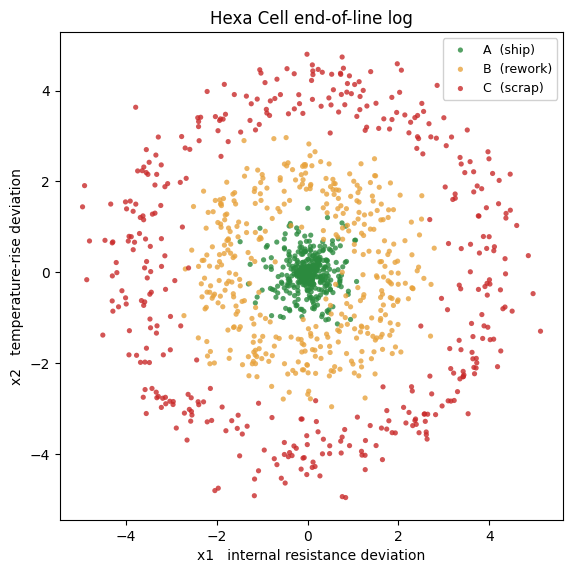

In [ ]:
GRADE_COLORS = ["#2b8a3e", "#e8a33d", "#c92a2a"]
GRADE_NAMES  = ["A  (ship)", "B  (rework)", "C  (scrap)"]


def plot_log(X, y, ax=None, s=14, alpha=0.8):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6.5, 6.5))
    for grade in range(3):
        mask = (y == grade)
        ax.scatter(X[mask, 0], X[mask, 1], s=s, alpha=alpha,
                   c=GRADE_COLORS[grade], label=GRADE_NAMES[grade],
                   edgecolors="none")
    ax.set_xlabel("x1   internal resistance deviation")
    ax.set_ylabel("x2   temperature-rise deviation")
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
    return ax


ax = plot_log(X, y)
ax.set_title("Hexa Cell end-of-line log")
plt.show()

### What the picture is telling us

Two things, and both of them matter more than any algorithm choice we are about to make.

**1. Feature engineering can change the problem completely.**
Before reaching for a more complex classifier, we should ask whether the features we have given the model actually capture the structure of the problem.

A model might see resistance and temperature as two independent numbers. But the real question may be **how far those values are from their nominal, healthy ranges**. By transforming the original features — for example, into deviations from nominal values, absolute deviations, ratios, or other meaningful combinations — we can expose patterns that were hidden in the original representation.

In other words, sometimes the problem is not that the classifier is too simple. **The features are simply not expressing the right information.**

**2. The boundary is not a line, and it could never have been one.**
Look at *why*. A cell is healthy when it sits close to nominal. It is faulty when it drifts far from nominal — and it does not matter *which way* it drifts. Resistance far above nominal is bad. Resistance far below nominal is also bad, for a different physical reason. The same is true of temperature rise.

A quantity that is dangerous at both extremes and safe in the middle cannot be split by a straight line. The healthy region is enclosed. The grades sit in rings.

This is not an artefact of our plot. It is what the physics of the process looks like, and a lot of real problems have exactly this shape.

**So before changing the classifier, we should ask: can we engineer features that make this structure easier for the model to learn?**


Which brings us to the obvious first move: we already know four families of classifiers. Let us see how far they get.

---

## Pulse check: can anything in our existing toolkit do this?

We will go through them one at a time, and for each one we want a precise diagnosis, not a verdict. "It doesn't work" is useless. "It fails because its hypothesis class only contains straight lines" is something we can act on.

### 1. Logistic Regression

- **Handles three classes?** Not directly. It is built for two. We can bolt on a one-vs-rest or one-vs-one scheme and run three separate models, but that is scaffolding we are adding, not something the model does natively.
- **Handles a curved boundary?** No. The boundary it can produce is always of the form `a*x1 + b*x2 = c`, which is a straight line, full stop.
- **Can we rescue it?** Yes, by hand. Feed it engineered features - squares, products, higher powers - and the boundary becomes curved in the original space. This is polynomial logistic regression.
- **The actual problem:** *we* have to invent those features. Someone has to sit down, stare at the plot, guess that squares might help, try it, and iterate. With two features and a 2D plot that is tedious. With four hundred sensor channels it is impossible, because there is no plot to stare at.

Let us confirm the failure rather than assert it.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

print("Logistic regression, raw features")
print("  train accuracy :", round(logreg.score(X_train, y_train), 3))
print("  test  accuracy :", round(logreg.score(X_test,  y_test),  3))
print("  random guessing:", round(1/3, 3))

Logistic regression, raw features
  train accuracy : 0.34
  test  accuracy : 0.343
  random guessing: 0.333


Roughly one in three. The model has learned nothing at all - it is doing what a coin with three faces would do. That is not underfitting in the usual sense. It is a model whose entire vocabulary is straight lines being asked to describe a circle.

### 2. K-Nearest Neighbours

- **Handles three classes?** Yes, natively. It just takes a vote among the neighbours.
- **Handles a curved boundary?** Yes. It makes no assumption about shape at all.
- **The actual problem:** it is non-parametric. There is no compact set of learned numbers - the training set *is* the model. To grade one cell at inference time it must compare that cell against the stored data. Our plant produces forty thousand cells a day; after a year the stored table is millions of rows, and the per-cell inference cost grows with it. The thing gets slower precisely as it gets better.
- A second problem specific to this data: near the boundary between two rings, the nearest points genuinely belong to both grades. Where the rings are tight, geometry alone cannot separate them.

### 3. Decision Trees

- **Handles three classes?** Yes.
- **Handles a curved boundary?** In a manner of speaking. Every split a tree makes is of the form `x1 < threshold` or `x2 < threshold`, so every boundary piece is parallel to an axis. A tree approximates our circle with a staircase of rectangles, and it needs a lot of depth to make that staircase fine enough.
- **The actual problem:** trees degrade badly on high-dimensional, sparse data - images, text, audio. Our plant has two sensors today, but the roadmap has a camera on that desk. The moment the input is a photograph of the cell, a tree is looking at tens of thousands of pixel columns and splitting on one pixel at a time. That does not work.

### 4. Support Vector Machines

- **Handles three classes?** Not directly, same as logistic regression. One-vs-rest or one-vs-one again.
- **Handles a curved boundary?** Yes, with a kernel. An RBF kernel would handle these rings well.
- **The actual problem:** cost at scale. Kernel methods need the kernel matrix, which has one entry for every pair of training points. For `m` training points that is an `m x m` matrix. At forty thousand cells a day, `m` reaches a million within a month, and a million-by-million matrix is not something we are going to hold.

Let us run all four and look at the numbers together.

In [ ]:
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.tree          import DecisionTreeClassifier
from sklearn.svm           import SVC

candidates = {
    "Logistic Regression"   : LogisticRegression(max_iter=1000),
    "KNN (k=15)"            : KNeighborsClassifier(n_neighbors=15),
    "Decision Tree (d=6)"   : DecisionTreeClassifier(max_depth=6, random_state=0),
    "Linear SVM"            : SVC(kernel="linear"),
    "RBF-kernel SVM"        : SVC(kernel="rbf"),
}

for name, model in candidates.items():
    model.fit(X_train, y_train)
    print(f"{name:<22}  test accuracy = {model.score(X_test, y_test):.3f}")

Logistic Regression     test accuracy = 0.343
KNN (k=15)              test accuracy = 0.970
Decision Tree (d=6)     test accuracy = 0.887
Linear SVM              test accuracy = 0.437
RBF-kernel SVM          test accuracy = 0.973


### Reading that table honestly

Some of these *do* score well. KNN and the RBF SVM both land around 0.97. So why are we not finished?

Because accuracy on 1200 toy rows is not the constraint. The constraints are the ones we listed: KNN's prediction cost grows with the number of training examples, kernel methods can require substantial memory as the dataset grows, and some of these model families do not naturally handle raw high-dimensional inputs such as images.

But there is a deeper limitation running through this entire exercise:

**a human being still has to decide what features the model should see.**

There is no single classical model here that takes arbitrary raw input and learns the entire representation end to end. We still have to decide how to represent the problem before the classifier can do its job.


---

### Quiz 1

**Question.** The Hexa Cell team gets a new requirement: within a year, the grading desk will also receive a 256 x 256 grayscale photograph of each cell, so the input becomes 65,538 features instead of 2. One team member proposes sticking with a decision tree "since it already handles the three classes and the curved boundary". What is the strongest technical objection to that plan?

A. Decision trees cannot be used for multi-class problems, so the three grades would need one-vs-rest wrappers.

B. Every split in a tree tests one feature against a threshold, so on high-dimensional pixel data the tree reasons one pixel at a time and cannot express relationships spread across many pixels.

C. Decision trees require all features to be standardised, and pixel intensities are not standardised.

D. Decision trees are non-parametric, so the training data must be stored and inference cost grows with the number of training cells.

**Answer: B**

**Explanation.**

- **B is correct.** A tree's hypothesis is a conjunction of single-feature threshold tests. Any single pixel carries almost no information on its own; what matters in an image is the pattern across neighbourhoods of pixels. To express such a pattern the tree would need an enormous number of splits, and it will latch onto noise long before it gets there. This is exactly the known weakness of trees on sparse, high-dimensional data such as images, text and audio.
- **A is wrong.** Decision trees handle multi-class natively - a leaf simply holds the majority class. No wrapper is needed. That objection applies to logistic regression and SVM, not trees.
- **C is wrong.** Trees are invariant to monotonic rescaling of any individual feature, because a split is just a threshold comparison. Standardisation is irrelevant to them. It matters for distance-based and gradient-based models.
- **D is wrong.** This describes KNN, not trees. A trained tree is a fixed structure of splits; the training data is discarded after fitting, and inference cost depends on tree depth, not on the number of training rows.

---

### Ask AI

Open any AI assistant and paste the prompt below. Replace the bracketed part with a dataset from your own work or a domain you know well.

> I am choosing a classifier for this problem: [describe your data - how many rows, how many features, how many classes, whether the features are raw sensor readings, images, text, or engineered columns].
>
> For each of logistic regression, KNN, decision trees and kernel SVM, tell me the single specific reason it would fail or become impractical on my problem. Do not give me a general pros-and-cons list. I want the failure mode that is actually triggered by my data's shape. If an algorithm would in fact work fine for my case, say so plainly instead of inventing a weakness.

**What to check in the reply.** A good answer names a mechanism - hypothesis class, memory growth, inference cost, dimensionality. A weak answer gives you a generic comparison table that would be identical for any dataset. If you get the second kind, push back with: "none of those reasons mention my data's dimensions - try again."

---

## Where the real gap is

Before we go looking for a new model, let us be precise about what is actually missing. A classifier does two separate jobs:

<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/226/795/original/ChatGPT_Image_Sep_11__2026__06_12_49_PM.png?1789130583" height=500>

Every algorithm we have studied does Job 2 well. Not one of them does Job 1. We do Job 1, with domain knowledge, a plotting library and patience.

Here is how sharp that distinction is on our own data. Logistic regression scored 0.34 - pure chance. Watch what one hand-built feature does to it.

In [ ]:
# One engineered feature: squared distance from nominal.
#   r2 = x1^2 + x2^2
# Physically: "how far has this cell drifted from nominal, regardless of direction"

r2_train = (X_train ** 2).sum(axis=1).reshape(-1, 1)
r2_test  = (X_test  ** 2).sum(axis=1).reshape(-1, 1)

X_train_aug = np.hstack([X_train, r2_train])   # now 3 features instead of 2
X_test_aug  = np.hstack([X_test,  r2_test])

logreg_aug = LogisticRegression(max_iter=1000)
logreg_aug.fit(X_train_aug, y_train)

print("Logistic regression, raw 2 features        :", round(logreg.score(X_test, y_test), 3))
print("Logistic regression, + one squared feature :", round(logreg_aug.score(X_test_aug, y_test), 3))

Logistic regression, raw 2 features        : 0.343
Logistic regression, + one squared feature : 0.973


From chance level to near-perfect. **The model did not change.** It is the same logistic regression, with the same straight-line hypothesis class, trained the same way. What changed is the space it was working in. In the space `(x1, x2, x1^2 + x2^2)`, the three rings become three flat slabs stacked on top of each other, and a flat boundary separates slabs perfectly well.

So the model was never the bottleneck. **The representation was.**

And that leaves us with the uncomfortable question: who invents `x1^2 + x2^2`?

Today, us - because there are two features and we can see the plot. Next year, when the desk has a camera and 65,538 pixel columns, nobody can. There is no plot. There is no physical intuition that says "square pixel 4,412 and add it to pixel 9,003".

So the requirement we are actually writing down is this:

### What we need

> **Requirement 1.** A model that discovers its own features instead of waiting for a human to hand them over.
>
> **Requirement 2.** A model that handles more than two classes without external scaffolding.
>
> **Requirement 3.** A model whose size and inference cost are fixed once trained, and do not grow as the plant collects more data.

Logistic regression already satisfies Requirement 3 - once it is trained, it is a handful of numbers, and grading a cell costs the same whether we trained on a thousand rows or a billion. That makes it the right thing to build on rather than throw away.

The question is what we have to add to it.

Before we answer that, it is worth noticing that models which meet all three requirements already exist, and we all used several of them this morning.

---

## Neural networks are already running most of your day

The plant manager drives in at seven. Between the alarm going off and reaching the desk, here is what she has already touched.

### Ranking and advertising

She searches for "cell winding machine supplier" and the results page carries sponsored listings that are unnervingly on-topic. Later, on a video app, she gets industrial equipment ads instead of the ones she got last week.

- The system estimates, for every candidate ad, the probability that this particular user clicks it right now.
- The inputs are the query, the page context, the time, the device, and a compressed summary of her history.
- Those inputs are raw and messy. Nobody hand-engineered "is an industrial buyer" as a column. The model built that notion itself.

### Data compression

Her photo app has thirty thousand pictures in it and is not asking her to pay for storage upgrades every month.

- A family of neural networks called **autoencoders** learns to squeeze an input down to a small internal code and then reconstruct the original from that code.
- The network is trained so that the reconstruction is close to the original, which forces the small code to keep the information that matters and discard what does not.
- We will study autoencoders properly later. The relevant point today is that the compressed representation is *learned*, not designed.

### Image editing and enhancement

She removes a stray pallet from a photo of the shop floor with one tap, and the background fills in convincingly.

- Underneath is **image segmentation**: every single pixel is classified into a category. Pixels belonging to the pallet get one label, floor pixels another, wall pixels another.
- Once the pallet's pixels are isolated they can be removed, and a second network predicts what was probably behind them.
- Note the scale of the classification problem. One prediction per pixel, millions of pixels, and the classes are not known in advance in any simple way.

### Text prediction

Her mail client offers three one-line replies, and she takes one.

- The model predicts likely continuations of text given everything written so far.
- It is the same family of idea that sits underneath the AI assistants you use. Different scale, same building block.

### What is common to all four

None of these systems was given hand-engineered features. In every case someone fed in raw input - queries, pixels, characters - and the model constructed its own intermediate representation on the way to the answer.

That is Requirement 1, solved, at industrial scale. So the natural question is: what are these systems made of?

Every one of them is built by repeating a single small unit, millions of times. And the blueprint for that unit came from the exact thing we are trying to replace at the Hexa Cell desk - a human making a judgement call.

---

## Inspiration from the biological neuron

### The control room

Forget the classifier for a moment and think about how a decision is actually made at a plant.

Hexa Cell has a control room. When something goes wrong on the line, the shift supervisor in that control room is the one who decides whether to halt production. She does not sense anything herself. Everything she knows arrives from other people:

- the rig operator, reporting test readings
- the maintenance technician, reporting vibration on the winding machine
- the QA sampler, reporting scrap counts from the last hour
- a junior trainee, reporting that something "seemed off"

Four incoming signals. She does not weigh them equally. The maintenance technician has been right about vibration every single time for six years, so his word counts heavily. The trainee started on Monday, so his word counts for very little - not zero, but very little. The rig operator's readings count moderately.

She combines what she has heard, weighted by how much she trusts each source. And then - this is the part that matters - **she does not act on every level of combined concern.** Small concern, she notes it and does nothing. As concern grows she gets more alert. Past a point, she picks up the phone and halts the line.

One more thing. Some supervisors are jumpy and halt the line at the slightest hint; others need overwhelming evidence. That personal trigger-happiness is a property of the supervisor, not of any of the four reports.

That is a complete description of a decision unit. Now look at a biological neuron.

### The biological neuron
<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/226/811/original/ChatGPT_Image_Sep_11__2026__06_30_17_PM.png?1789131626" height=500>

- A neuron is connected to many other neurons through **dendrites**, which is how signals reach it.
- Those connections are not identical. **Some dendrites are physically thicker than others**, and a signal arriving on a thick connection influences the cell far more than the same signal arriving on a thin one.
- The **cell body** accumulates everything that has arrived.
- If the accumulated signal crosses a **threshold**, the neuron **fires** and sends a signal down its **axon** to the next neurons. Below the threshold, it stays quiet.
- That threshold is a property of the neuron itself, independent of any incoming signal.

Set the two side by side.

### The mapping

| Control room | Biological neuron | Machine learning |
|---|---|---|
| Four people reporting | Signals arriving on dendrites | **Features** `x1, x2, ..., xd` |
| How much she trusts each person | Thickness of each dendrite | **Weights** `w1, w2, ..., wd` |
| Combining reports by trust level | Cell body accumulating input | **Weighted sum** |
| How jumpy this supervisor is | The neuron's own firing threshold | **Bias** `b` |
| Deciding whether to halt the line | Firing, or staying quiet | **Activation function** `f` |
| The decision she announces | The signal sent down the axon | **Output** `o` |

Three things are worth pausing on.

**A weight is an importance, and it is signed.** A large positive weight means "when this input goes up, push towards firing". A large negative weight means "when this input goes up, push *away* from firing". A weight near zero means this input is being ignored. The trainee is not a negative signal; he is close to zero.

**The bias belongs to the unit, not to any input.** It shifts how much total evidence is needed before the unit responds at all. Two neurons receiving identical inputs with identical weights can behave completely differently if one has a large positive bias and the other a large negative one.

**Importantly, weights are learned.** Nobody handed the supervisor a trust table on her first day. She built it over six years of seeing who turned out to be right. In our setting, that is what training does - and the mechanism for it is gradient descent, which we covered last session.

### One caution before we move on

The analogy is genuinely useful and genuinely limited. An artificial neuron is a loose caricature of a biological one - real neurons involve timing, chemistry and dynamics that we are not modelling at all. Nobody claims otherwise. The inspiration was historical; the mathematics stands on its own.

---

### Quiz 2

**Question.** A neuron takes two inputs. Input `x1` is a temperature reading in degrees Celsius, typically in the range 20 to 90. Input `x2` is a vibration reading in millimetres per second, typically in the range 0.1 to 0.6. After training, the learned weights are `w1 = 0.04` and `w2 = 3.1`. A colleague concludes that vibration is roughly 75 times more important than temperature to this neuron. What is wrong with that conclusion?

A. Nothing is wrong. The weight magnitude is exactly the importance of the feature, so vibration is about 75 times more important.

B. Weight magnitudes are only comparable when the features are on comparable scales. Temperature moves across a range about 140 times wider than vibration, so a small weight on temperature can still produce a larger contribution to the sum.

C. The conclusion is wrong because only the sign of a weight carries meaning, and both weights here are positive.

D. The conclusion is wrong because importance is determined by the bias term, which has not been given.

**Answer: B**

**Explanation.**

- **B is correct.** The neuron computes a sum of `w * x` terms, so what a feature actually contributes is the product, not the weight alone. Temperature spans roughly 70 units, so its contribution spans about `0.04 x 70 = 2.8`. Vibration spans roughly 0.5 units, so its contribution spans about `3.1 x 0.5 = 1.55`. Temperature is in fact contributing *more* variation to the sum, which is the opposite of the stated conclusion. Comparing raw weight magnitudes is only valid after the features have been put on a common scale - which is one of the reasons feature scaling matters.
- **A is wrong.** It is the exact error being tested. Weight magnitude is importance per unit of the input, and the units differ.
- **C is wrong.** Sign is not the only meaningful part. Magnitude carries real information - it is simply not interpretable across features on different scales.
- **D is wrong.** The bias shifts the threshold at which the unit responds. It is a single number added to the sum regardless of input, so it cannot make one feature more important than another.

**The practical takeaway.** If you want to read weights as feature importances, standardise your features first. Then the comparison is meaningful, because a one-unit move means the same thing for every input.

---

## Writing the supervisor down as an equation

We have described the unit in words. Words do not train. Let us turn that description into mathematics, one piece at a time, defining every symbol as it appears.

### Notation for the dataset

Fix this vocabulary now; we will use it for the rest of the class.

- **`m`** - the number of training examples. For the Hexa Cell log, `m = 900` in the training split.
- **`d`** - the number of input features per example. Here `d = 2`.
- **`x_i`** - the `i`-th training example, a vector of `d` numbers, written `x_i = [x_i1, x_i2, ..., x_id]`.
- **`x_ij`** - the `j`-th feature of the `i`-th example. So `x_5,2` is the temperature-rise deviation of the fifth logged cell.
- **`y_i`** - the true label of the `i`-th example. Here `y_i` is one of 0, 1, 2.
- **`X`** - the full feature matrix, with `m` rows and `d` columns. Row `i` is `x_i`.

When we drop the subscript `i` and just write `x`, we mean a single generic example.

### Step 1: the weighted sum

The unit receives `d` inputs. Each input `x_j` has a weight `w_j` attached to it - one weight per input, learned during training.

- **`w_j`** - a real number, the weight on input `j`. Large positive means input `j` pushes the unit towards a high output; large negative pushes it the other way; near zero means it is being ignored.
- **`b`** - a single real number, the bias, belonging to the unit itself. It is added regardless of what the inputs are.
- **`z`** - a single real number, the result of this step. It is called the **net input** or the **pre-activation**.

The weighted sum is:

$$ z = w_1 x_1 + w_2 x_2 + \cdots + w_d x_d + b $$

which we can write compactly as

$$ z = \sum_{j=1}^{d} w_j x_j + b $$

or, treating `w` and `x` as vectors of length `d`,

$$ z = w^T x + b $$

where `w^T x` denotes the dot product of `w` and `x`, and `w^T` is the transpose of `w`.

For the Hexa Cell desk, with `d = 2`, that is simply:

$$ z = w_1 x_1 + w_2 x_2 + b $$

with `x1` the resistance deviation and `x2` the temperature-rise deviation.

### What `w` and `b` actually do, geometrically

This is the part that makes everything later feel obvious rather than arbitrary, so it is worth going slowly.

Set `z = 0` and ask which points in the plane satisfy it:

$$ w_1 x_1 + w_2 x_2 + b = 0 $$

That is the equation of a **straight line** in the `(x1, x2)` plane. In `d` dimensions the same equation describes a flat `(d-1)`-dimensional sheet, called a **hyperplane**. This hyperplane splits the whole space into two halves: the points where `z > 0` and the points where `z < 0`.

Now the two roles:

**The vector `w` sets the orientation.** `w` points perpendicular to that line, in the direction along which `z` increases fastest. Analogy: `w` is the direction of "downhill" on a tilted floor. If `w = [1, 0]`, then `z` grows purely as `x1` grows and the dividing line is vertical. If `w = [1, 1]`, the line runs diagonally.

**The number `b` sets the position.** Changing `b` slides that line back and forth without rotating it. Solving `w1*x1 + w2*x2 + b = 0` for the intercept shows the shift directly. Analogy: `b` is the sensitivity dial on a smoke alarm. It does not change *what* the alarm is listening to - that is `w` - it changes *how much* is needed before it goes off.

**The magnitude of `z` measures distance.** For any point `x`, the perpendicular distance from that point to the line is

$$ \text{distance} = \frac{|z|}{\lVert w \rVert} $$

where `||w||` is the length of the vector `w`, that is `sqrt(w_1^2 + w_2^2 + ... + w_d^2)`.

So `z` is not just a number - it is a signed, scaled measure of *which side of the line the point is on, and how far from it*. Sign gives the side. Magnitude gives the confidence. That is the entire content of a linear model, and we will use both halves in a moment.

### Step 2: the activation function

If we stopped at `z`, the unit's output would be an unbounded real number. That is not a decision, and the supervisor in the control room did not behave that way - she stayed quiet below a level of concern and acted above it.

So the unit applies a function to `z`:

- **`f`** - the **activation function**, a function from one real number to one real number.
- **`o`** - the unit's **output**, `o = f(z)`.

Putting both steps together, the complete artificial neuron is:

$$ o = f(z) = f\left(\sum_{j=1}^{d} w_j x_j + b\right) $$

Or, as a slogan worth memorising:

> **Neuron = linear part, then activation.**

The linear part is `w^T x + b`. The activation is whatever `f` we choose. Everything in this course is built out of that pair.

### The flow, drawn out

<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/226/816/original/ChatGPT_Image_Sep_11__2026__06_38_47_PM.png?1789132144" height=500>

Read left to right: this is a **forward pass**. We will name it properly shortly.

### The common activation functions

Four that you will meet immediately. Each one is a choice about *how* the unit converts a signed distance into a response.

**Step function** - the literal version of "fires or does not fire".

$$ f(z) = \begin{cases} 1 & \text{if } z \ge 0 \\ 0 & \text{if } z < 0 \end{cases} $$

It is an ordinary light switch. It throws away the magnitude of `z` entirely - a point barely across the line and a point a mile across get identical output. It is also flat everywhere, which will turn out to be fatal for training, for reasons that come up when we do backpropagation.

**Sigmoid** - the smooth version.

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

where `e` is Euler's number, about 2.718. Properties worth knowing by heart:

- The output always lies strictly between 0 and 1, which lets us read it as a probability.
- `sigma(0) = 0.5` exactly. The dividing line `z = 0` is precisely the half-way point.
- Large positive `z` sends it towards 1; large negative `z` sends it towards 0.
- It is smooth everywhere, so it has a derivative everywhere - which is what makes gradient-based training possible.

It is a dimmer switch rather than a light switch. It keeps the magnitude information that the step function discarded, and reports confidence rather than only a verdict.

**Tanh** - the same S-shape, recentred.

$$ \tanh(z) = \frac{e^{z} - e^{-z}}{e^{z} + e^{-z}} $$

Output lies between -1 and 1, and `tanh(0) = 0`. Being centred at zero is often convenient during training.

**ReLU** - rectified linear unit.

$$ \text{ReLU}(z) = \max(0, z) $$

Pass the signal through unchanged if it is positive; block it completely if it is negative. It is a one-way valve. It is crude, it is not even smooth at zero, and it is the default choice in most modern networks - we will see why when we study training.

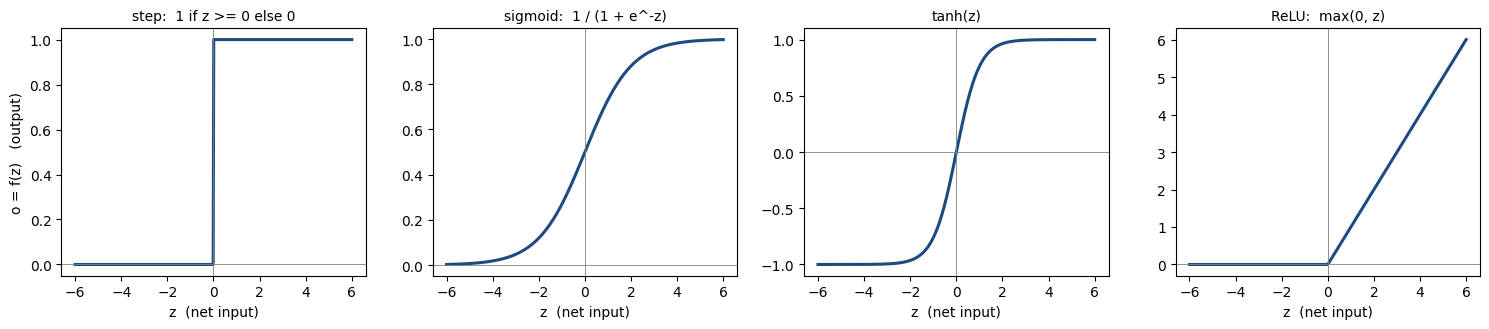

In [ ]:
z_grid = np.linspace(-6, 6, 500)

activations = {
    "step:  1 if z >= 0 else 0"  : (z_grid >= 0).astype(float),
    "sigmoid:  1 / (1 + e^-z)"   : 1 / (1 + np.exp(-z_grid)),
    "tanh(z)"                    : np.tanh(z_grid),
    "ReLU:  max(0, z)"           : np.maximum(0, z_grid),
}

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, (name, values) in zip(axes, activations.items()):
    ax.plot(z_grid, values, lw=2.2, color="#1c4b82")
    ax.axhline(0, lw=0.6, color="gray")
    ax.axvline(0, lw=0.6, color="gray")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("z  (net input)")
axes[0].set_ylabel("o = f(z)   (output)")
plt.tight_layout()
plt.show()

---

### Quiz 3

**Question.** A single neuron at the Hexa Cell desk has been trained with `w1 = 1.5`, `w2 = -0.5`, `b = -2.0`, and a sigmoid activation. A cell arrives with readings `x1 = 2.0` and `x2 = -1.0`. Which of the following is correct?

A. `z = 1.5` and the output is approximately 0.82.

B. `z = 2.5` and the output is approximately 0.92.

C. `z = 1.5` and the output is approximately 0.18.

D. `z = -0.5` and the output is approximately 0.38.

**Answer: A**

**Explanation.**

Compute the net input first, substituting into `z = w1*x1 + w2*x2 + b`:

```
z = (1.5)(2.0) + (-0.5)(-1.0) + (-2.0)
  =    3.0     +     0.5      +  (-2.0)
  = 1.5
```

Note the middle term. Both the weight and the feature are negative, so their product is *positive*. That sign flip is the most common slip in this calculation.

Now apply the sigmoid:

```
sigma(1.5) = 1 / (1 + e^-1.5)
           = 1 / (1 + 0.2231)
           = 1 / 1.2231
           = 0.8176
```

So `z = 1.5` and `o = 0.82` approximately.

- **B is wrong.** It comes from treating the second term as `(-0.5)(-1.0) = -0.5`, or from dropping the bias.
- **C is wrong.** It has the correct `z` but reports `sigma(-1.5)` instead of `sigma(1.5)`. Remember that `z` is positive here, and sigmoid of a positive number must exceed 0.5.
- **D is wrong.** It comes from adding the bias with the wrong sign somewhere in the sum.

**The intuition behind the number.** `z = 1.5` is positive, so this cell sits on the "high output" side of the neuron's dividing line, and 1.5 units of net input away from it in the scaled sense. The sigmoid converts that into 0.82 - the unit is fairly confident, but not certain. Had `z` been 5.0, the output would have been 0.993 and the unit would be practically certain.

---

## Why the activation function is not optional

It would be reasonable to ask: **why do we even need an activation function?** Why not just keep using a simple equation and make it more complicated?

Let's start with the simplest possible model.

Suppose we have:

$$
y = 2x + 3
$$

This is a linear equation. No matter what value of $x$ we give it, the relationship between $x$ and $y$ always follows a straight line.

Now suppose we make the equation more complicated:

$$
y = 2(3x + 4) + 5
$$

At first glance, this looks more powerful. But simplify it:

$$
y = 6x + 13
$$

We are **back to another linear equation**.

We can keep adding more linear operations:

$$
y = 2(3(4x + 1) + 5) + 7
$$

and after simplifying, we will still get:

$$
y = ax + b
$$

for some values of $a$ and $b$.

So simply stacking more linear equations does not give us a fundamentally new kind of function. **A complicated-looking chain of linear operations is still just a linear relationship.**

### So where does non-linearity come from?

We need to introduce an operation that cannot be simplified back into the form:

$$
y = ax + b
$$

For example:

$$
y = (2x + 3)^2
$$

Now the relationship contains $x^2$:

$$
y = 4x^2 + 12x + 9
$$

This is no longer a straight line. It can represent curves and much more complex relationships.

That is the role of an **activation function**. It introduces non-linearity into the computation.

**The conclusion:** Non-linearity is not decoration. Without it, repeatedly applying linear operations only gives us another linear function. Adding more layers of computation does not automatically make the model more expressive.

The same logic becomes especially important when we move to **neural networks**. There, we will see how activation functions allow different layers to build increasingly complex representations from simpler ones.

---

### Ask AI

Paste this into any AI assistant. The goal is to make it hand you a worked example that you then verify by hand - not to make it do the work for you.

> Generate one worked numerical example of a forward pass through a single artificial neuron with three inputs and a sigmoid activation. Pick the weights, bias and input values yourself and make sure at least one weight and one input are negative. Show the value of z and the final output.
>
> Then generate a second example of the same kind, but deliberately introduce exactly one arithmetic mistake somewhere in the working, without telling me where it is. Label the two examples clearly as Example 1 and Example 2, and do not reveal which one contains the error.

**After the session.** Work through both by hand, decide which one is broken and where, then ask the assistant to confirm. Two things are being trained here: the mechanics of the forward pass, and the habit of checking AI output against your own arithmetic rather than trusting it. Both matter.

---

## Doing this for all the cells at once

At the desk, cells arrive one at a time and we compute one `z` per cell. In code we never loop over rows - we compute the whole batch with one matrix multiplication. Getting the shapes right is most of the battle, so let us be explicit.

**Symbols:**

- **`X`** - the input matrix, shape `(m, d)`. Rows are cells, columns are features.
- **`W`** - the weight matrix for a layer of `h` units, shape `(d, h)`. Column `k` holds the `d` weights belonging to unit `k`.
- **`b`** - the bias vector, shape `(1, h)`. One bias per unit.
- **`Z`** - the net inputs, shape `(m, h)`. Entry `(i, k)` is the net input of unit `k` on cell `i`.
- **`A`** - the activated outputs, shape `(m, h)`.

$$ Z = X W + b \qquad A = f(Z) $$

Shape check, which is the thing to internalise:

<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/226/818/original/ChatGPT_Image_Sep_11__2026__06_39_55_PM.png?1789132204" heoght=500>

The inner dimensions must agree - `d` inputs meeting `d` weights - and the outer dimensions survive: `m` cells in, `m` results out; `h` units in the layer, `h` numbers per cell.

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# One layer of h = 4 units sitting on our d = 2 features.
d = X_train.shape[1]
h = 4

rng = np.random.default_rng(0)
W = rng.normal(0, 0.5, size=(d, h))     # (2, 4)  one column per unit
b = np.zeros((1, h))                    # (1, 4)  one bias per unit

Z = X_train @ W + b                     # (900, 2) @ (2, 4) -> (900, 4)
A = sigmoid(Z)                          # (900, 4)

print("X_train :", X_train.shape, " <- m cells, d features")
print("W       :", W.shape,       " <- d features, h units")
print("b       :", b.shape,       " <- one bias per unit")
print("Z       :", Z.shape,       " <- m cells, h net inputs")
print("A       :", A.shape,       " <- m cells, h outputs")

print("\nFirst cell's readings :", np.round(X_train[0], 3))
print("Its 4 net inputs z    :", np.round(Z[0], 3))
print("Its 4 outputs f(z)    :", np.round(A[0], 3))

X_train : (900, 2)  <- m cells, d features
W       : (2, 4)  <- d features, h units
b       : (1, 4)  <- one bias per unit
Z       : (900, 4)  <- m cells, h net inputs
A       : (900, 4)  <- m cells, h outputs

First cell's readings : [-0.236  0.842]
Its 4 net inputs z    : [-0.24   0.168  0.473  0.386]
Its 4 outputs f(z)    : [0.44  0.542 0.616 0.595]


Four units looked at the same cell and each returned a different number, because each one has its own column of weights - its own `w` direction and its own dividing line. Four opinions on one cell. That plurality is where a network's power is going to come from.

Right now those weights are random, so the opinions are meaningless. Training is what turns them into something. That mechanism - computing the gradient of the loss with respect to every weight and stepping downhill - is gradient descent, which we built from scratch in the previous session. It plugs in here unchanged. What is new today is only the *shape* of the function we are differentiating.

---

## Interactive playground 1: one neuron, live

Move the sliders and watch what a single neuron can and cannot express.

- **`w1`, `w2`** rotate the dividing line.
- **`b`** slides it without rotating it.
- The **activation** dropdown changes how the net input `z` is converted into an output, but notice it never changes *where* the boundary sits.

The black line on both panels is the set of points where `z = 0`.

In [ ]:
from ipywidgets import interact, FloatSlider, Dropdown


def neuron_playground(w1=1.0, w2=1.0, b=0.0, activation="sigmoid"):
    grid = np.linspace(-6, 6, 300)
    xx, yy = np.meshgrid(grid, grid)

    Z = w1 * xx + w2 * yy + b               # the linear part

    if   activation == "sigmoid": O = sigmoid(Z)
    elif activation == "tanh":    O = np.tanh(Z)
    elif activation == "relu":    O = np.maximum(0, Z)
    elif activation == "step":    O = (Z >= 0).astype(float)
    else:                         O = Z     # no activation

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))

    surface = axes[0].contourf(xx, yy, O, levels=30, cmap="RdYlGn")
    axes[0].contour(xx, yy, Z, levels=[0], colors="k", linewidths=2.2)
    plt.colorbar(surface, ax=axes[0], label="neuron output   o = f(z)")
    axes[0].set_title(f"o = {activation}( {w1:.1f}*x1 + {w2:.1f}*x2 + {b:.1f} )")
    axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2"); axes[0].set_aspect("equal")

    plot_log(X, y, ax=axes[1], s=11, alpha=0.75)
    axes[1].contour(xx, yy, Z, levels=[0], colors="k", linewidths=2.2)
    axes[1].set_xlim(-6, 6); axes[1].set_ylim(-6, 6)
    axes[1].set_title("the same boundary, on the Hexa Cell log")

    plt.tight_layout()
    plt.show()


interact(
    neuron_playground,
    w1=FloatSlider(value=1.0, min=-3, max=3, step=0.1, description="w1"),
    w2=FloatSlider(value=1.0, min=-3, max=3, step=0.1, description="w2"),
    b =FloatSlider(value=0.0, min=-6, max=6, step=0.2, description="b"),
    activation=Dropdown(options=["sigmoid", "tanh", "relu", "step", "none"],
                        value="sigmoid", description="activation"),
);

interactive(children=(FloatSlider(value=1.0, description='w1', max=3.0, min=-3.0), FloatSlider(value=1.0, desc…

### What the demonstration establishes

Three observations, in order.

**Changing `w1` and `w2` rotates the line; changing `b` translates it.** Exactly as the algebra said. The two knobs do different jobs and they do not interfere.

**Changing the activation changes the shading, never the line.** Sigmoid gives a soft gradient, step gives a hard edge, ReLU clips one side flat. But the black line stays exactly where it was, because the boundary is determined by `z = 0`, and `f` is applied *after* `z` is computed. An activation function reshapes the response; it does not move the decision surface of a single unit.

**No setting of the three sliders classifies the rings.** Try. There is no combination. The healthy cells sit in the middle of the plane, surrounded on all sides, and a straight line cannot enclose a region.

One neuron is one straight cut through the space. That is its entire vocabulary.

Which is a good moment to notice that we have built this object before, under a different name.

---

## Logistic Regression is a neuron

Put the two definitions next to each other.

**A neuron with sigmoid activation:**

$$ z = w_1 x_1 + w_2 x_2 + \cdots + w_d x_d + b \qquad o = \sigma(z) = \frac{1}{1 + e^{-z}} $$

**Logistic regression, exactly as we wrote it earlier in the course:**

$$ z = w_1 x_1 + w_2 x_2 + \cdots + w_d x_d + b \qquad \hat{y} = \frac{1}{1 + e^{-z}} $$

These are not similar. They are the same equation with different letters.

Every logistic regression model any of us has ever trained was a single artificial neuron with a sigmoid activation. Nothing has been hidden from us; we simply had no reason to draw it as a unit with inputs flowing in.

This object has a name: a **Logistic Regression Unit**. It bundles two operations - a linear combination, then a non-linearity - into one repeatable block.

### Drawn as a unit, for our two features

```
                   w1
   x1 -------------------\
                          \
                           >---[ z = w1*x1 + w2*x2 + b ]---[ sigmoid ]---> o
                          /                                              in (0,1)
   x2 -------------------/
                   w2
                              b (bias, added always)
```

The two boxes are the two halves of the slogan: **linear, then activation.**

### Forward propagation

Moving from the inputs, through the unit, to the output is called **forward propagation**, or a **forward pass**. The whole of it, for one cell, is:

1. Take the readings `x1` and `x2`.
2. Compute `z = w1*x1 + w2*x2 + b`.
3. Compute `o = f(z)`.
4. Compare `o` with the true label `y` to get the loss.

That is it. Four steps, and we have already implemented every one of them.

The reverse journey - taking the loss and working backwards through the network to find how each weight should change - is called **backpropagation**. We are not doing it today. It is the subject of the next session, and it is, at its heart, the chain rule of derivatives applied systematically.

```
                forward propagation
         ------------------------------->
   input          network            loss
         <-------------------------------
                backpropagation
                (next session)
```

### What we gain by the renaming

Recognising logistic regression as a neuron does not improve logistic regression. What it gives us is a **building block with a standard interface**: `d` numbers in, one number out, `d + 1` parameters inside.

A block with a standard interface can be repeated. And its output, being a number, can be fed into another block of the same kind. That is the whole idea of a network, and we could not have had it without first noticing that the model we already had was shaped like a block.

---

## Other models that are also one neuron

If sigmoid gives us logistic regression, a reasonable question is what the other activations give us. The skeleton `z = w^T x + b` stays identical; only `f` changes.

**Step activation gives the perceptron.** This is the oldest one, built by Rosenblatt in 1957 - the first thing that could reasonably be called a neural network model.

$$ z = w^T x + b \qquad o = \begin{cases} 1 & z \ge 0 \\ 0 & z < 0 \end{cases} $$

It outputs a hard verdict with no notion of confidence. A cell one micrometre past the line and a cell far past it get the same answer.

**Hinge-type behaviour gives the linear SVM.** A linear support vector machine is, at its core, the same linear unit trained against a hinge loss with an L2 penalty on the weights. The forward computation is again:

$$ z = w^T x + b \qquad o = f_{\text{hinge}}(z) $$

What separates SVM from logistic regression is not the architecture - it is the loss function being minimised and the regularisation attached to it.

**Summary of single-neuron models:**

| Model | Activation `f` | Output means |
|---|---|---|
| Perceptron (1957) | step | a hard class verdict |
| Logistic Regression | sigmoid | probability of the positive class |
| Linear SVM | hinge-based | a signed margin |

Three models that occupy separate chapters in a classical ML course, and they differ only in what happens after the weighted sum.

This is the moment to appreciate the leverage. **One neuron already contains three of the most important models in classical machine learning.** So what does a network of them contain?

---

## Handling three grades, not two

Requirement 2 was multi-class without external scaffolding. The neuron framing solves it almost for free, and it is worth seeing how because the mechanism is used everywhere.

Instead of one output unit, use **one output unit per class**. For Hexa Cell that is three, one each for grades A, B and C. Each has its own weights and its own bias, so each produces its own net input:

- **`z_k`** - the net input of output unit `k`, for `k = 1, 2, 3`. Computed as `z_k = w_k^T x + b_k`, where `w_k` is that unit's own weight vector and `b_k` its own bias.

Three numbers, one per grade. We need to turn them into three probabilities that are all positive and sum to one.

### Why not just use three sigmoids?

We could apply a sigmoid independently to each output:

$$
p_k = \sigma(z_k)
$$

But sigmoid treats each output independently. There is nothing forcing the three outputs to be **mutually exclusive** or to add up to one.

For example, the model could produce:

$$
[0.9,\ 0.8,\ 0.7]
$$

Does that mean the cell is 90% A, 80% B and 70% C? Those numbers don't form a valid probability distribution for a single class prediction.

We need the outputs to **compete with each other**: increasing the score for one class should affect the relative probabilities of the others.

That is what the **softmax** function does:

$$
p_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}
$$

where:

- **`K`** - the number of classes, here 3.
- **`p_k`** - the predicted probability that this cell belongs to class `k`.
- **`e`** - Euler's number, about 2.718.

Two things this does. The exponential makes every value positive, so nothing can come out as a negative probability. Dividing by the sum of all of them forces the results to total exactly one. The predicted grade is then whichever `p_k` is largest.

Softmax is the multi-class generalisation of sigmoid - with `K = 2` it reduces to exactly the sigmoid we have been using. No one-vs-rest wrapper, no three separate models, no external scaffolding. Three units and one normalisation step, trained together as one model.

<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/226/834/original/ChatGPT_Image_Sep_11__2026__06_54_18_PM.png?1789133069" height=500>

---

## From one neuron to a network

We established that one neuron is one straight cut. Our rings need a closed region. So: what does a *collection* of neurons give us?

Think about it physically. One straight fence divides a field into two. Two fences at an angle carve out a wedge. Three fences can enclose a triangle. Four can enclose a quadrilateral. Eight can enclose an octagon - and an octagon is already a decent approximation of a circle.

**Nobody has to tell each fence where to stand.** Each unit has its own `w` and its own `b`, and training moves them. What emerges is a set of cuts that, taken together, enclose the healthy region.

And this is precisely what "learning your own features" means in practice. Each hidden unit computes a number - "how far is this cell past my particular line" - and those numbers, collectively, form a new description of the cell. A later layer works in that description rather than in raw sensor readings. Nobody wrote down `x1^2 + x2^2`. The network assembled something that does the same job.

### The structure

```
   INPUT LAYER         HIDDEN LAYER              OUTPUT LAYER
   (the readings)      (learned features)        (the grades)

      x1 ------------>  ( h1 )  ------------\
         \         /    ( h2 )  -------------\-----> ( A )
          \       /     ( h3 )  --------------+-----> ( B )   -> softmax
           \     /      ( h4 )  -------------/-----> ( C )
      x2 ------------>  ( h5 )  ------------/

      every input          every hidden unit        one unit per class
      connects to          has its own w and b
      every hidden unit
```

Vocabulary, since we will use it constantly:

- **Input layer** - the raw features. It holds no parameters; it is just where the data enters.
- **Hidden layer** - any layer between input and output. "Hidden" only because its outputs are never directly observed - we do not have labels for what `h3` should be, and we never need them.
- **Output layer** - produces the final prediction, one unit per class here.
- **Fully connected** (or **dense**) - every unit in a layer receives input from every unit in the previous layer.
- **Depth** - the number of layers. **Width** - the number of units in a layer.

### Counting the parameters

Worth being able to do in your head, because it tells you how big a model actually is.

A fully connected layer with `n_in` inputs and `n_out` units holds:

- `n_in x n_out` weights - every input connects to every unit, and each of those connections carries one weight.
- `n_out` biases - one per unit.

$$ \text{parameters in a layer} = n_{in} \times n_{out} + n_{out} $$

For the small network drawn above: 2 inputs, 5 hidden units, 3 output units.

- Hidden layer: `2 x 5 + 5 = 15`
- Output layer: `5 x 3 + 3 = 18`
- **Total: 33 parameters.**

Thirty-three numbers, learned by gradient descent, and that is the entire model. Once trained, grading a cell costs the same whether the plant logged a thousand cells or a billion. That is Requirement 3, and it is what KNN and kernel SVM could not give us.

---

### Quiz 4

**Question.** An engineer builds a network with an input layer, eight hidden layers of 512 units each, and an output layer - and forgets to apply any activation function anywhere, so every layer computes only `xW + b`. She trains it on the Hexa Cell data. What will she observe, and why?

A. The network will successfully learn the ring-shaped regions because the eight hidden layers give it enough capacity to carve out complex boundaries.

B. The network will perform poorly, because the entire network is mathematically equivalent to a single linear layer and can only produce a straight-line boundary.

C. The network will perform very well on training data but poorly on test data, because a network that deep will overfit badly.

D. Training will fail to converge at all, because without an activation function the gradients are undefined.

**Answer: B**

**Explanation.**

- **B is correct.** Composing linear maps gives a linear map. As derived above, `o = x(W1 W2 ... W9) + b'`, and the product of those weight matrices is a single `d x k` matrix. So this 8-layer, roughly two-million-parameter network has exactly the expressive power of plain logistic regression - it can only place a straight boundary. On rings, that is insufficient to separate the classes.

- **A is wrong.** Capacity in terms of parameter count is not the same as expressive power. The parameters are real and they are being trained, but they are all being spent re-parameterising a single linear map. Millions of parameters, one straight line.

- **C is wrong.** Overfitting means fitting the training data too closely, including its noise. This network cannot fit the training data closely in the first place. This is severe underfitting, which is the opposite failure.

- **D is wrong.** The gradients are perfectly well defined. Training will run, the loss will decrease, and it will converge - to the best straight-line solution, which happens to be useless here. This is what makes the bug dangerous: nothing crashes and nothing warns you.

## Interactive playground 2: how many neurons does the ring need?

One hidden layer, and a slider for how many units are in it. Everything else is held fixed. Watch the shape of the region the network carves out.

In [ ]:
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap
from ipywidgets import IntSlider

REGION_CMAP = ListedColormap(GRADE_COLORS)


def capacity_demo(n_hidden=4):
    net = MLPClassifier(hidden_layer_sizes=(n_hidden,),
                        activation="relu",
                        max_iter=4000,
                        random_state=1)
    net.fit(X_train, y_train)

    grid = np.linspace(-6, 6, 260)
    xx, yy = np.meshgrid(grid, grid)
    preds = net.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    n_params = (sum(a.size for a in net.coefs_)
                + sum(a.size for a in net.intercepts_))

    fig, ax = plt.subplots(figsize=(6.8, 6.8))
    ax.contourf(xx, yy, preds, levels=[-0.5, 0.5, 1.5, 2.5],
                colors=GRADE_COLORS, alpha=0.22)
    plot_log(X_train, y_train, ax=ax, s=10, alpha=0.85)
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
    ax.set_title(
        f"hidden units = {n_hidden}    parameters = {n_params}    "
        f"test accuracy = {net.score(X_test, y_test):.3f}"
    )
    plt.tight_layout()
    plt.show()


interact(
    capacity_demo,
    n_hidden=IntSlider(value=4, min=1, max=16, step=1, description="hidden units"),
);

interactive(children=(IntSlider(value=4, description='hidden units', max=16, min=1), Output()), _dom_classes=(…

### What to watch as the slider moves

**One hidden unit.** One straight cut. Accuracy sits near chance, exactly as our single-neuron playground predicted. Nothing about calling it a "neural network" helps.

**Two units.** Two cuts, forming a wedge. Better than chance, still nowhere near usable.

**Four units.** The shaded region becomes a quadrilateral. Four straight cuts have enclosed the healthy zone. Accuracy jumps to around 0.97, and the total parameter count is 27.

**Eight units.** An octagon. Sixteen units, a shape close enough to a circle that the corners stop being visible.

Three conclusions, and they are the payoff of the whole session.

**Each hidden unit contributes one straight cut.** The curvature is not inside any single unit - it emerges from combining many linear pieces. This is why the units must be non-linear: without `f`, the combination collapses back to one cut, as we proved.

**Four units and 27 parameters beat a model that had to store 900 training rows.** Recall the RBF SVM scoring 0.973 here. Similar accuracy, but this network is 27 numbers, and it stays 27 numbers no matter how much data the plant collects.

**Nobody engineered a feature.** We never wrote `x1^2 + x2^2`. The network found its own way to express "distance from nominal", built out of four straight cuts. That was Requirement 1, and it is the thing that makes all of this worth the trouble.

This raises an obvious question. If four neurons solve a problem that defeated our entire classical toolkit, and the idea has been around since 1957 - why has the Hexa Cell plant been doing this by hand for eleven years? Why is this not a solved problem from decades ago?

The answer is a genuinely strange piece of history.

---

## A brief history of artificial neural networks

<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/226/837/original/ChatGPT_Image_Sep_11__2026__07_00_12_PM.png?1789133426" height=600 width= 1200>

### Why this matters for the plant

Hexa Cell has been sorting cells by hand for eleven years, and that was the correct decision for most of them. What changed is not the algorithm. What changed is that the plant now runs forty thousand cells a day through an instrumented line, every reading is logged automatically, and a laptop can train this model in seconds.

The mathematics was available in 1986. The preconditions were not.

---

## Neural networks versus classical ML, as data grows

The history section had a lesson buried in it that is worth extracting properly, because it is how you decide which family to reach for.

<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/226/839/original/ChatGPT_Image_Sep_11__2026__07_05_03_PM.png?1789133732" height=500>

### Reading the plot

**On the left, where data is scarce, classical ML is competitive and often better.** It climbs fast and it climbs early. A well-tuned gradient-boosted tree on a few thousand rows of tabular data will frequently beat a neural network, and will certainly be faster to build. This is not a consolation prize - it is the correct choice in that regime, and most business problems live in that regime.

**Classical methods flatten out.** Past a point, adding more data stops helping them. Their capacity to express structure is bounded by the feature engineering we gave them, and more rows do not buy more features.

**Neural networks start slower and keep climbing.** With little data they overfit or fail to train - there are not enough examples to determine all those parameters. But their ceiling is far higher, and they keep converting extra data into extra performance long after the classical curves have gone flat.

**Bigger networks need more data to get going, and reach higher.** The three green curves are the same family at different sizes. Capacity you cannot feed is capacity that hurts you.

The operational rule: **the amount of labelled data you have is a primary input into model choice, not an afterthought.** Deep learning is not universally better. It is better in a specific regime, and the regime is defined mostly by data volume.

---

---

### Ask AI

> I have just learned that logistic regression, the perceptron and a linear SVM are all a single artificial neuron differing only in activation function and loss function.
>
> Extend that lineage forward for me. Starting from one neuron, list the sequence of architectural ideas that leads to the large language models in use today, and for each step state the single specific limitation of the previous step that it removed. Keep it to one sentence per step. Do not give me a timeline of company announcements - I want the chain of architectural problems and solutions.

**What you are looking for.** A chain where each item removes a named weakness of the one before it: one neuron cannot make a curved boundary, so stack layers; stacked layers cannot be trained, so backpropagation; dense layers on images ignore spatial structure and have far too many parameters, so convolution; and onwards. If the reply is a list of dates and product names, ask again for the problem-solution chain specifically.

---

### One piece of arithmetic worth doing

We counted the parameters in our four-unit network: 27. Use the same formula, `n_in * n_out + n_out`, on the assistant you have been prompting all session.

A layer with 4,096 inputs and 4,096 units holds `4096 x 4096 + 4096 = 16,781,312` parameters. Roughly 16.8 million - from one layer. Large models stack many such layers alongside other components, which is how published parameter counts reach the hundreds of billions.

Every one of those parameters sits in exactly the structure we wrote on the board today: a weighted sum, a bias, an activation function. The assistant that just quizzed you on what an activation function does is itself made out of them, arranged by the same slogan - **linear, then activation** - repeated at a scale that is hard to picture but not hard to describe.

That is the honest version of what "AI" refers to. You now know what it is made of.

---

## Wrap-up

- **Our existing toolkit fails on the Hexa Cell data, and each one fails for a specific reason.** Logistic regression and linear SVM can only draw straight boundaries. KNN keeps the entire training set and gets slower as it gets more data. Trees split one feature at a time and collapse on high-dimensional input. Kernel SVM needs an `m x m` matrix that becomes unaffordable at scale.

- **The bottleneck was never the boundary-drawing. It was the representation.** The same logistic regression that scored 0.34 scored 0.97 once we handed it `x1^2 + x2^2`. Classical ML does Job 2 well and leaves Job 1 to a human, and Job 1 becomes impossible as soon as the input is pixels or text.

- **An artificial neuron is a weighted sum followed by an activation.** `z = w1*x1 + ... + wd*xd + b`, then `o = f(z)`. The vector `w` orients the dividing hyperplane, the scalar `b` slides it, and `|z| / ||w||` is the distance from a point to it. Weights are importances and are signed; the bias belongs to the unit, not to any input.

- **The mapping from biology is direct.** Dendrites are features, dendrite thickness is weights, the cell body is the weighted sum, the firing threshold is the bias, firing is the activation function. Useful as intuition, not as biology.

- **Without the activation function, depth is worthless.** Composing linear layers gives `o = xW' + b'` - a single linear layer. A hundred layers with no non-linearity draw one straight line.

- **Logistic regression is one neuron with a sigmoid.** The perceptron is one neuron with a step. A linear SVM is the same unit with a hinge loss. Three classical models, one skeleton, different activations and losses.

- **Forward propagation** is input to output; **backpropagation** is the reverse pass that computes gradients, and it is the chain rule applied layer by layer. That is the next session.

- **Multi-class needs no scaffolding.** One output unit per class, then softmax `p_k = e^{z_k} / sum_j e^{z_j}` to turn the scores into probabilities that sum to one.

- **Each hidden unit is one straight cut, and many cuts enclose a curved region.** Four units made a quadrilateral around the healthy cells and hit 0.97 with 27 parameters. Eight made an octagon. The curvature emerges from combination, which is exactly why the units must be non-linear.

- **A layer with `n_in` inputs and `n_out` units has `n_in * n_out + n_out` parameters,** and that count is fixed after training regardless of how much data was used. This is what KNN and kernel SVM could not offer.

- **The mathematics was ready in 1986; the data and the hardware were not.** Backpropagation solved the training problem, two AI winters followed for reasons of compute and data volume, and ImageNet in 2012 marked the point where both constraints lifted.

- **Data volume is a primary input into model choice.** Classical methods climb quickly and flatten early; neural networks start slower and keep climbing. Neither family is universally better.

- **AI is a study tool whose output must be audited.** Fluency and correctness are independent. Use it to examine you and to generate variation, and check every claim you cannot yet derive.

---